In [6]:
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPinocchioModel import RobotPinocchioModel
from optimal.RobotController import RobotController
from optimal.configuration import UR10, Trajectories
import optimal.metrics as metrics
import numpy as np

type = UR10
robot_mj_model = RobotMujocoModel(type.mjcf_path, type.list_of_joints)
robot_pin_model = RobotPinocchioModel(type.urdf_path, type.list_of_joints)

DT = robot_mj_model.model.opt.timestep
path = Trajectories.joint_6dof
nq = len(robot_pin_model.q_indices)
nv = len(robot_pin_model.v_indices)

MAX_ERROR_DEG = 0.5  # hard ceiling on the position error


def evaluate(kp, kd, DT, path, time_limit=1000, max_error_deg=MAX_ERROR_DEG, get_xs_us=False):
    controller = RobotController(robot_pin_model)
    xs, us = [], []
    try:
        current_q = path[0]
        current_v = np.zeros(nv)
        for i in range(1, len(path)):
            x_start = np.concatenate([current_q, current_v])
            x_goal = np.concatenate([path[i], np.zeros(nv)])
            t_xs, t_us = controller.compute_control(
                x_start=x_start, x_goal=x_goal,
                T=time_limit, DT=DT, kp=kp, kd=kd, option="pd")
            current_q = t_xs[-1][:nq]
            current_v = t_xs[-1][nq:]
            xs.extend(t_xs)
            us.extend(t_us)
    except Exception as e:
        print(f"Solver failed with error: {e}")
        if get_xs_us:
            return float("inf"), [], []
        return float("inf")
    prec_deg = metrics.tracking_error(xs, path[1:], [time_limit] * (len(path) - 1))
    energy = metrics.thermal_energy(us, DT) + metrics.mechanical_work(us, xs, DT)
    score = energy
    if prec_deg > max_error_deg:
        score += 1e9 * (prec_deg - max_error_deg)  # hard precision barrier
    if get_xs_us:
        return float("inf") if np.isnan(score) else float(score), xs, us
    return float("inf") if np.isnan(score) else float(score)


def params_to_arrays(p):
    kp = np.array([p[f"kp{i}"] for i in range(1, 7)])
    ratio = np.array([p[f"ratio{i}"] for i in range(1, 7)])
    return kp, kp * ratio, ratio


In [18]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    # Wrist gains (kp4-6) share the body range now: soft wrist gains were the main
    # reason the steady-state MuJoCo error stayed high (error ~ gravity_mismatch/kp).
    kp = np.array([trial.suggest_float(f"kp{i}", 1, 2e3, log=True) for i in range(1, 7)])
    ratio = np.array([trial.suggest_float(f"ratio{i}", 0.05, 0.15) for i in range(1, 7)])
    return evaluate(kp, kp * ratio, DT, path)


In [19]:
from optuna.samplers import TPESampler

study_tpe = optuna.create_study(direction="minimize", sampler=TPESampler(seed=0))
study_tpe.optimize(objective, n_trials=500, show_progress_bar=True)
kp_tpe, kd_tpe, ratio_tpe = params_to_arrays(study_tpe.best_params)
print("TPE best score:", study_tpe.best_value)
print("TPE kp:", np.round(kp_tpe, 3))
print("TPE kd:", np.round(kd_tpe, 3))

Best trial: 408. Best value: 93480.2: 100%|██████████| 500/500 [00:55<00:00,  9.06it/s]  

TPE best score: 93480.19453907263
TPE kp: [127.131 290.697 445.568  18.581   2.656   3.985]
TPE kd: [18.656 37.663 26.893  2.695  0.142  0.21 ]


In [20]:
from optuna.samplers import CmaEsSampler

study_cma = optuna.create_study(direction="minimize", sampler=CmaEsSampler(seed=0))
study_cma.optimize(objective, n_trials=500, show_progress_bar=True)
kp_cma, kd_cma, ratio_cma = params_to_arrays(study_cma.best_params)
print("CMA-ES best score:", study_cma.best_value)
print("CMA-ES kp:", np.round(kp_cma, 3))
print("CMA-ES kd:", np.round(kd_cma, 3))

Best trial: 305. Best value: 109771: 100%|██████████| 500/500 [00:45<00:00, 11.11it/s]   

CMA-ES best score: 109771.05299548552
CMA-ES kp: [ 139.025 1780.884  190.977   64.861   10.345    5.   ]
CMA-ES kd: [ 20.393 266.007  18.196   7.075   1.013   0.295]


In [3]:
def coordinate_grid_search(kp_grids, ratio_grids, kp_init, ratio_init,
                           DT, path, n_passes=3, verbose=True):
    # Per-joint coarse grid searched one joint at a time (coordinate descent).
    # A full Cartesian product of 6 kp x 6 ratio axes is intractable
    # (e.g. 5**12 ~ 2.4e8 evaluations), so each joint's (kp, ratio) sub-grid is
    # swept while the other joints are held at their current best value.
    kp = np.array(kp_init, dtype=float)
    ratio = np.array(ratio_init, dtype=float)
    best = evaluate(kp, kp * ratio, DT, path)
    n_eval = 1
    for p in range(n_passes):
        improved = False
        for j in range(len(kp)):
            for kp_val in kp_grids[j]:
                for r_val in ratio_grids[j]:
                    t_kp = kp.copy()
                    t_kp[j] = kp_val
                    t_ratio = ratio.copy()
                    t_ratio[j] = r_val
                    s = evaluate(t_kp, t_kp * t_ratio, DT, path)
                    n_eval += 1
                    if s < best:
                        best, kp, ratio, improved = s, t_kp, t_ratio, True
        if verbose:
            print(f"Pass {p + 1}: best = {best:.4e}  (evals: {n_eval})")
        if not improved:
            break
    return kp, ratio, best, n_eval


# Energy-minimising objective in Pinocchio: the grid spans low-to-moderate gains
# so the search can find the softest gains that still settle within 0.5 deg.
kp_grids = [
    np.array([5, 20, 60, 150, 400]),
    np.array([5, 20, 60, 150, 400]),
    np.array([5, 20, 60, 150, 400]),
    np.array([1, 5, 15, 40, 100]),
    np.array([1, 5, 15, 40, 100]),
    np.array([1, 5, 15, 40, 100]),
]
ratio_grids = [np.array([0.05, 0.10, 0.15])] * 6
kp_init = np.array([60.0, 60.0, 60.0, 15.0, 15.0, 15.0])
ratio_init = np.array([0.10] * 6)

kp_grid, ratio_grid, score_grid, n_eval = coordinate_grid_search(
    kp_grids, ratio_grids, kp_init, ratio_init, DT, path, n_passes=4)
kd_grid = kp_grid * ratio_grid
print("Grid best score:", score_grid, " evaluations:", n_eval)
print("Grid kp:", np.round(kp_grid, 3))
print("Grid kd:", np.round(kd_grid, 3))


Pass 1: best = 5.8443e+10  (evals: 91)
Pass 2: best = 3.3037e+09  (evals: 181)
Pass 3: best = 9.8984e+04  (evals: 271)
Pass 4: best = 9.8872e+04  (evals: 361)
Grid best score: 98871.6658661366  evaluations: 361
Grid kp: [150. 400. 150. 100.  40.   1.]
Grid kd: [22.5  60.   15.   15.    2.    0.15]


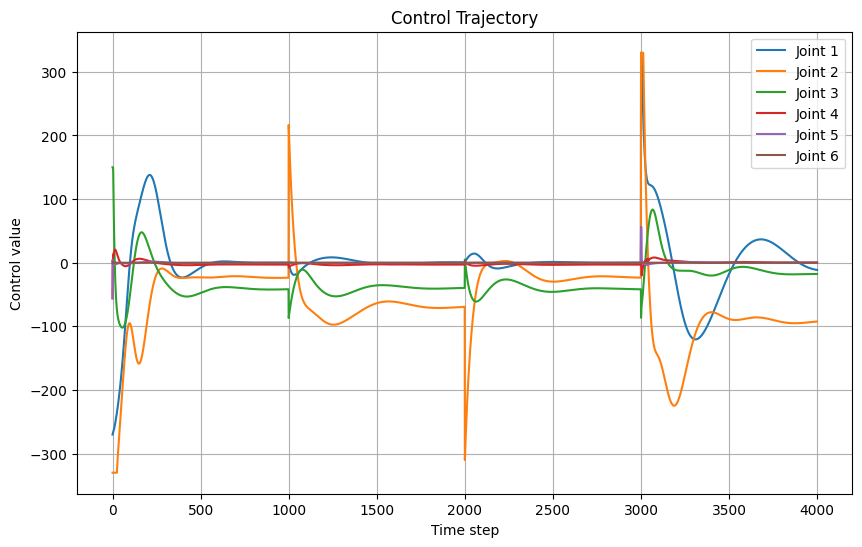

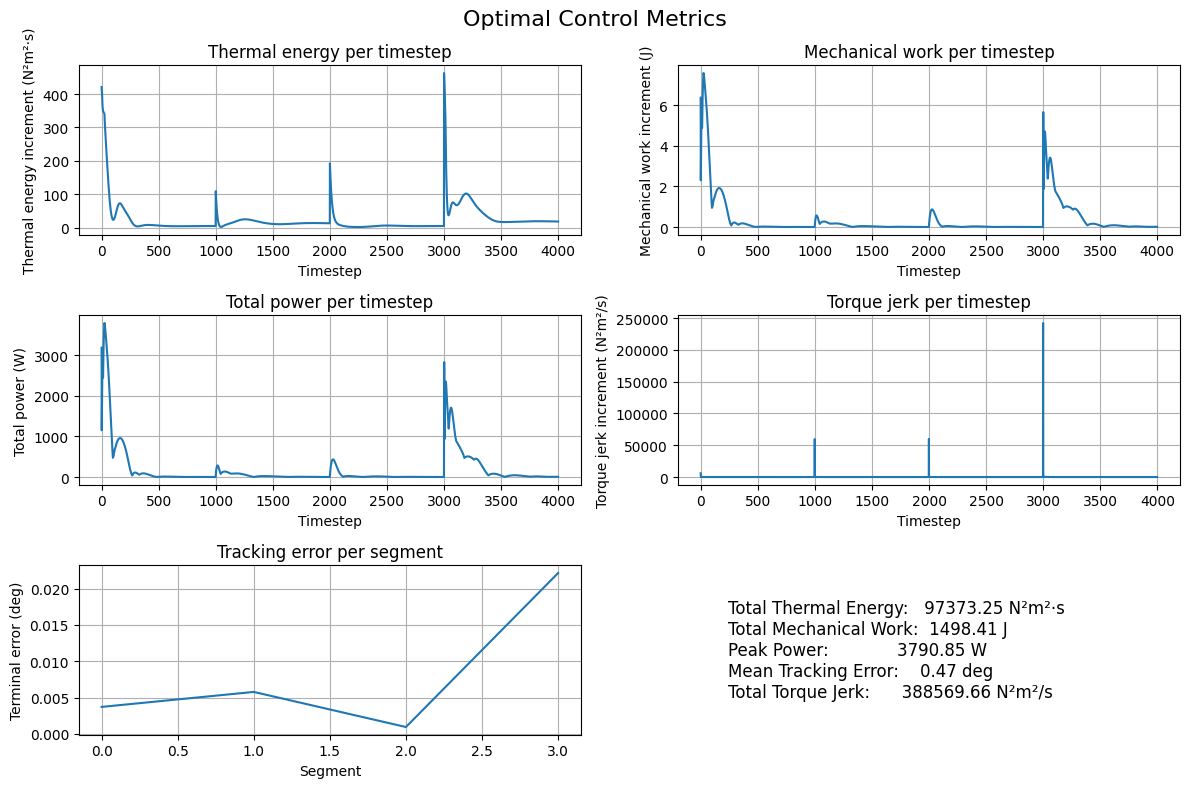

In [13]:
robot_mj_model.reset()
_, xs, us = evaluate(kp_grid, kd_grid, DT, path, time_limit=1000, get_xs_us=True)
# robot_mj_model.visualize("position", xs=xs)
robot_mj_model.plot_controls(us)
from optimal.metrics import plot_metrics
plot_metrics(us, xs, DT, path[1:], [1000] * (len(path) - 1))

In [22]:
results = {
    "TPE": (kp_tpe, kd_tpe, study_tpe.best_value),
    "CMA-ES": (kp_cma, kd_cma, study_cma.best_value),
    "Grid": (kp_grid, kd_grid, score_grid),
}
print(f"{'Method':<10}{'Score':>16}")
print("-" * 26)
for name, (_, _, s) in sorted(results.items(), key=lambda kv: kv[1][2]):
    print(f"{name:<10}{s:>16.4e}")

best_opt_name = "CMA-ES" if study_cma.best_value <= study_tpe.best_value else "TPE"
kp_opt, kd_opt, score_opt = results[best_opt_name]
ratio_opt = kd_opt / kp_opt
print(f"\nBest Optuna: {best_opt_name} ({score_opt:.4e})")
print(f"Grid:        {score_grid:.4e}")
print("Optuna beats grid:", score_opt < score_grid)

Method               Score
--------------------------
TPE             9.3480e+04
Grid            9.8670e+04
CMA-ES          1.0977e+05

Best Optuna: TPE (9.3480e+04)
Grid:        9.8670e+04
Optuna beats grid: True


In [23]:
def refine_optuna(kp_opt, ratio_opt, DT, path,
                  kp_factors=(0.85, 0.93, 1.0, 1.07, 1.15),
                  ratio_offsets=(-0.02, -0.01, 0.0, 0.01, 0.02), n_passes=3):
    # Local per-joint grid centred on the Optuna optimum: refine each kp by a set
    # of multiplicative factors and each ratio by small additive offsets, reusing
    # the same coordinate-descent grid routine.
    kp_grids = [kp_opt[j] * np.array(kp_factors) for j in range(len(kp_opt))]
    ratio_grids = [np.clip(ratio_opt[j] + np.array(ratio_offsets), 0.01, 0.3)
                   for j in range(len(ratio_opt))]
    return coordinate_grid_search(kp_grids, ratio_grids, kp_opt, ratio_opt,
                                  DT, path, n_passes=n_passes)


kp_ref, ratio_ref, score_ref, n_eval_ref = refine_optuna(kp_opt, ratio_opt, DT, path)
kd_ref = kp_ref * ratio_ref
print(f"Optuna ({best_opt_name}) before refine: {score_opt:.4e}")
print(f"Grid-refined Optuna:           {score_ref:.4e}")
print(f"Improvement:                   {(1 - score_ref / score_opt) * 100:.2f}%  ({n_eval_ref} evals)")
print("Refined kp:", np.round(kp_ref, 3))
print("Refined kd:", np.round(kd_ref, 3))

Pass 1: best = 8.9508e+04  (evals: 151)
Pass 2: best = 8.9508e+04  (evals: 301)
Optuna (TPE) before refine: 9.3480e+04
Grid-refined Optuna:           8.9508e+04
Improvement:                   4.25%  (301 evals)
Refined kp: [127.131 311.046 414.379  15.794   2.258   3.387]
Refined kd: [21.198 43.41  20.867  2.606  0.098  0.212]


In [24]:
from optimal.metrics import thermal_energy, mechanical_work, peak_power, tracking_error

candidates = {
    "TPE": (kp_tpe, kd_tpe, study_tpe.best_value),
    "CMA-ES": (kp_cma, kd_cma, study_cma.best_value),
    "Grid": (kp_grid, kd_grid, score_grid),
    "Grid-refined Optuna": (kp_ref, kd_ref, score_ref),
}
best_name = min(candidates, key=lambda k: candidates[k][2])
best_kp, best_kd, best_score = candidates[best_name]
print(f"Overall best: {best_name}  (score {best_score:.4e})")
print("kp:", np.round(best_kp, 3))
print("kd:", np.round(best_kd, 3))

# Open-loop Pinocchio validation (same rollout the optimisation was scored on).
controller = RobotController(robot_pin_model)
xs, us = [], []
current_q = path[0]
current_v = np.zeros(nv)
for i in range(1, len(path)):
    x_start = np.concatenate([current_q, current_v])
    x_goal = np.concatenate([path[i], np.zeros(nv)])
    t_xs, t_us = controller.compute_control(
        x_start=x_start, x_goal=x_goal,
        T=1000, DT=DT, kp=best_kp, kd=best_kd, option="pd")
    current_q = t_xs[-1][:nq]
    current_v = t_xs[-1][nq:]
    xs.extend(t_xs)
    us.extend(t_us)

prec = tracking_error(xs, path[1:], [1000] * (len(path) - 1))
print("\nPinocchio open-loop validation of best params:")
print("Thermal energy:", thermal_energy(us, DT))
print("Mechanical work:", mechanical_work(us, xs, DT))
print("Peak power:", peak_power(us, xs))
print(f"Tracking error [deg]: {prec:.4f}")
print(f"Requirement < 0.5 deg: {'PASS' if prec < 0.5 else 'FAIL'}")


Overall best: Grid-refined Optuna  (score 8.9508e+04)
kp: [127.131 311.046 414.379  15.794   2.258   3.387]
kd: [21.198 43.41  20.867  2.606  0.098  0.212]

Pinocchio open-loop validation of best params:
Thermal energy: 88049.08171538291
Mechanical work: 1458.8483640711247
Peak power: 6243.504698896739
Tracking error [deg]: 0.4991
Requirement < 0.5 deg: PASS


In [27]:
robot_mj_model.reset()
controller = RobotController(robot_pin_model)
xs, us = [], []
current_q = path[0]
current_v = np.zeros(nv)
for i in range(1, len(path)):
    x_start = np.concatenate([current_q, current_v])
    x_goal = np.concatenate([path[i], np.zeros(nv)])
    t_xs, t_us = controller.compute_control(
        x_start=x_start, x_goal=x_goal,
        T=1000, DT=DT, kp=best_kp, kd=best_kd, option="pd")
    current_q = t_xs[-1][:nq]
    current_v = t_xs[-1][nq:]
    xs.extend(t_xs)
    us.extend(t_us)

prec = tracking_error(xs, path[1:], [1000] * (len(path) - 1))
print("\nMuJoCo open-loop validation of best params:")
print("Thermal energy:", thermal_energy(us, DT))
print("Mechanical work:", mechanical_work(us, xs, DT))
print("Peak power:", peak_power(us, xs))    
print(f"Tracking error [deg]: {prec:.4f}")

xs_real, us_real = robot_mj_model.visualize("control", us=us, xs=xs, kp=type.kp, kd=type.kd, dt=DT, hold=False)


MuJoCo open-loop validation of best params:
Thermal energy: 88049.08171538291
Mechanical work: 1458.8483640711247
Peak power: 6243.504698896739
Tracking error [deg]: 0.4991
